# Flood PAHM Disruption - MWI | vector analysis

## **Health Emergencies Preparedness and Response Program (HEPR)**

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities.\
It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a vector-based implementation of market access, using the road network from [OpenStreetMap Project](https://download.geofabrik.de/).\
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## Setup

Import packages required for the analysis

In [1]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [3]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
import dask_geopandas as dask_gpd

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
from pyquadkey2 import quadkey

In [4]:
# Climate/Flood
# import xarray as xr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
data_dir = join(expanduser("/home/jupyter-wb618081"), 'data')
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics')
out_path = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Output')

In [1]:
## Function for creating a path, if needed ##
def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

## Data Preparation

### Administrative boundaries

In [174]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:32736"

In [173]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
adm2 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=2)

In [10]:
# iso = 'MWI'
# adm0_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin0_Polys.shp')
# adm0 = gpd.read_file(adm0_path)
# adm0 = adm0[adm0["ISO3"] == "MWI"].to_crs(4326)

# iso = 'MWI'
# adm2_path = join(expanduser("R:/"), 'Data', 'GLOBAL/ADMIN', f'Admin2_Polys.shp')
# adm2 = gpd.read_file(adm2_path)
# adm2 = adm2[adm2["ISO3"] == "MWI"].to_crs(4326)

### Population (origin)

In [11]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_path = join(data_dir, f'ppp_2020_1km_Aggregated.tif') # Download from link above

pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [12]:
hf_path = join(data_dir,'MWI','HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)

display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(df_hf["Facility Type"].value_counts())

# Consider all health facilities and hospitals

df_hf_hosp = df_hf.loc[df_hf['Facility Type'] == "Hospital"]

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Facility Type
Outreach          5090
Village Clinic    3542
Health Centre      542
Health Post        152
Dispensary          87
Hospital            85
Name: count, dtype: int64

In [13]:
# Convert from pandas.Dataframe to Geopandas.dataframe

geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs=epsg
)

geodf_hf_hosp = gpd.GeoDataFrame(
    df_hf_hosp, geometry=gpd.points_from_xy(df_hf_hosp.Eastings, df_hf_hosp.Northings), crs=epsg
)

# Clean the geodf
geodf_hf = geodf_hf[['Facility Name', 'Facility Type','District', 'TA', 'geometry']]; geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf_hosp = geodf_hf_hosp[['Facility Name', 'Facility Type', 'District', 'TA', 'geometry']]; geodf_hf_hosp.loc[:, 'ID'] = df_hf_hosp.index


Assure correspondence of ADM1 names in Health facilities and official Administrative Units

In [14]:
geodf_hf.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
geodf_hf_hosp.rename(columns={'District': 'ADM1', 'TA': 'ADM2'}, inplace=True)
adm1.rename(columns={"NAME_1":"ADM1"}, inplace=True) 

# The following ADM1 are not corresponding
miss_adm1 = np.setdiff1d(np.sort(geodf_hf.ADM1.unique()), np.sort(adm1.ADM1.unique()))
display(miss_adm1)
display(np.setdiff1d(np.sort(adm1.ADM1.unique()), np.sort(geodf_hf.ADM1.unique())))

array(['Mzimba North', 'Mzimba South'], dtype=object)

array(['Mzimba'], dtype=object)

In [15]:
for adm in miss_adm1:
    for idx in (geodf_hf[geodf_hf.ADM1 == adm].index):
            geodf_hf.loc[idx, 'ADM1'] = 'Mzimba'

    for idx_hosp in (geodf_hf_hosp[geodf_hf_hosp.ADM1 == adm].index):
            geodf_hf_hosp.loc[idx_hosp, 'ADM1'] = 'Mzimba'

### Flood

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [16]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

# inland waters and oceans: 999
# not-flooded areas: -999 (Fluvial)
# not-flooded areas: 0 (Pluvial)
# Other values represent the flood depth (in m)

flood_fluvial_path = join(data_dir, iso,'FLOOD_SSBN','fluvial_undefended')
flood_pluvial_path = join(data_dir, iso,'FLOOD_SSBN','pluvial')

files=os.listdir(flood_fluvial_path)
flood_dict_fluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_fluvial_path,file)) #.read(1)
    flood_dict_fluvial[key] = value

files=os.listdir(flood_pluvial_path)
flood_dict_pluvial = {}
for file in files:
    key = file.split('_')[1].split('.')[0]
    value = rio.open(join(flood_pluvial_path,file)) #.read(1)
    flood_dict_pluvial[key] = value

# Preserve the maximum flood depth
flood_dict = {}
for f,key in enumerate(flood_dict_pluvial.keys()):
    out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
    if os.path.isfile(out_flood_path):
        value = rio.open(out_flood_path) 
        flood_dict[key] = value
    else:
        out_meta = flood_dict_pluvial[key].meta
        flood_max = np.fmax(flood_dict_fluvial[key].read(1),flood_dict_pluvial[key].read(1))
        flood_dict[key] = flood_max
        # flood_dict[key][flood_dict[key] == 0] = -999
        # Write the output raster
        out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key +'.tif')
        with rio.open(out_flood_path, 'w', **out_meta) as dst:
            dst.write(flood_max, 1)
        # Read the output raster
        value = rio.open(out_flood_path) 
        flood_dict[key] = value

# Free up memory
for f,key in enumerate(flood_dict.keys()):
        del flood_dict_fluvial[key]
        del flood_dict_pluvial[key]

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [17]:
# Only the first time, clip the travel friction surface to the country of interest
out_travel_surface = join(data_dir, iso, f"travel_surface_motorized_{iso}.tif")

if not os.path.isfile(out_travel_surface):
    gfs_path = join(data_dir, '2020_motorized_friction_surface.geotiff')
    gfs_rio = rio.open(gfs_path)
    rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

# Import the clipped friction surface
travel_surf = rio.open(out_travel_surface) #.read(1)

In [18]:
print(travel_surf.res)
print(pop_surf.res)

(0.008333333333333333, 0.008333333333333333)
(0.0083333333, 0.0083333333)


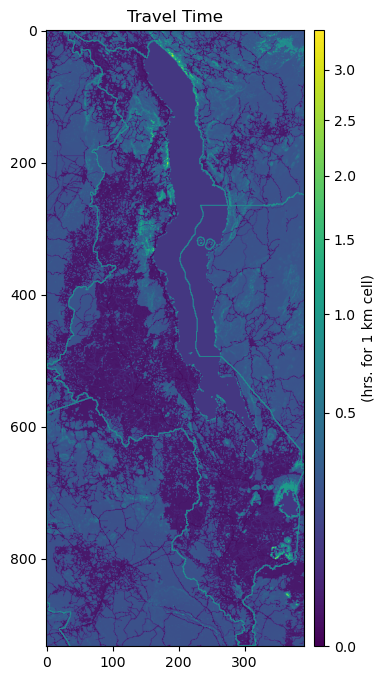

In [19]:
fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Travel Time", fontsize=12, horizontalalignment='center')
im = ax.imshow(travel_surf.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(hrs. for 1 km cell)")

### Preprocessing



Align the POPULATION & FLOOD raster to the friction surface, ensuring that they have the same extent and resolution.

In [20]:
# If the Standardized data are already present, skip, else generate them

def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

out_pop_surface_std = join(out_path, iso, "WP_2020_1km_STD.tif")
if not os.path.isfile(out_pop_surface_std):
    rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

checkDir(join(scratch_dir, 'data', iso, 'flood'))

for f,key in enumerate(flood_dict.keys()):
    # out_flood_path = join(data_dir, iso,'FLOOD_SSBN', 'Fmax_' + key)
    out_flood_std = join(out_path, iso, 'flood', "STD_" + 'Fmax_'+ key +'.tif')
    if os.path.isfile(out_flood_std):
        None
    else:
        rMisc.standardizeInputRasters(flood_dict[key], travel_surf, out_flood_std, resampling_type="nearest")

Correct the reprojected FLOOD raster extension, ensuring that lands are not covered by inland and open waters

In [21]:
# Import multiple rasterio .tif file as a dictionary
# Keys are return periods
# Values are rasterio arrays

flood_path = join(out_path, iso, 'flood')
files=os.listdir(flood_path)

flood_dict_std = {}
for file in files:
    if file.startswith('STD') == True:
        key = file.split('_')[2].split('.')[0]
        value = rio.open(join(flood_path,file)) #.read(1)
        flood_dict_std[key] = value

display(flood_dict_std["1in10"].read_crs())

CRS.from_epsg(4326)

### Origins

Prepare a standard grid (pandas.Dataframe) using each cell from the 1km World Pop raster.

In [23]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

(32.67083333333333, -9.3625)

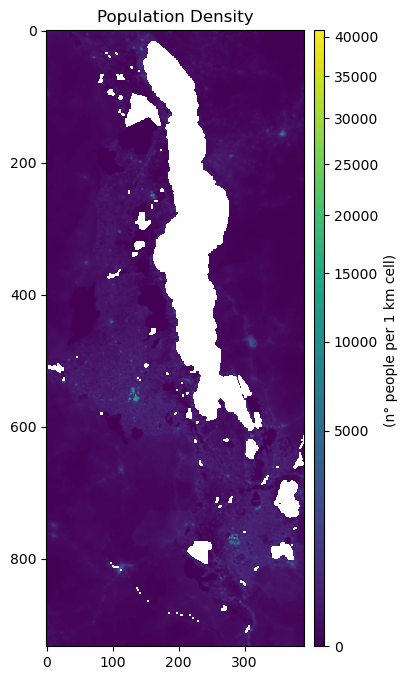

In [24]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
ax.set_title("Population Density", fontsize=12, horizontalalignment='center')
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size="4%", pad=0.1)
cb = fig.colorbar(im, cax=cax, orientation='vertical')
cb.set_label("(n° people per 1 km cell) ")

pop_surf.xy(0,0)

In [25]:
# Create a population df from population surface 
indices = list(np.ndindex(pop.shape))
xys = [Point(pop_surf.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices,
    'xy': xys,
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67083333333333 -9.3625),67.614548,0
1,"(0, 1)",POINT (32.67916666666666 -9.3625),70.830971,1
2,"(0, 2)",POINT (32.68749999999999 -9.3625),96.481911,2
3,"(0, 3)",POINT (32.695833333333326 -9.3625),111.579651,3
4,"(0, 4)",POINT (32.70416666666666 -9.3625),161.928329,4
...,...,...,...,...
363865,"(932, 385)",POINT (35.879166666666656 -17.129166666666666),32.535667,363865
363866,"(932, 386)",POINT (35.88749999999999 -17.129166666666666),24.958359,363866
363867,"(932, 387)",POINT (35.89583333333332 -17.129166666666666),14.960836,363867
363868,"(932, 388)",POINT (35.904166666666654 -17.129166666666666),14.153514,363868


## Flood impact on Health facilities

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution\
For every Standardized Flood layer (Return Period), extract Flood Depth on Health Facilities location

In [26]:
# Extract flood depth at every facility location

for key in flood_dict.keys():
    coords = [(x,y) for x, y in zip(geodf_hf_hosp.geometry.x, geodf_hf_hosp.geometry.y)]
    geodf_hf_hosp[key] = [x[0] for x in flood_dict[key].sample(coords)]

    coords = [(x,y) for x, y in zip(geodf_hf.geometry.x, geodf_hf.geometry.y)]
    geodf_hf[key] = [x[0] for x in flood_dict[key].sample(coords)]


In [27]:
# Identify Flooded and not Flooded Facilities 

flood_geodf_hf_hosp = {}
dry_geodf_hf_hosp = {}
flood_geodf_hf = {}
dry_geodf_hf = {}
for key in flood_dict.keys():
    flood_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] > 0.2]
    dry_geodf_hf_hosp[key] = geodf_hf_hosp[geodf_hf_hosp[key] == 0]
    
    flood_geodf_hf[key] = geodf_hf[geodf_hf[key] > 0.2]
    dry_geodf_hf[key] = geodf_hf[geodf_hf[key] == 0]


### Summary statistics

For every Flood Scenario (RP):
- Number and % of Health facilities disrupted by Facility Type
- Number and % of Health facilities disrupted by ADM1 Districts

In [28]:
# Reorder Flood Return Periods in geodf columns

def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if col.startswith(str_start)]
    non_fd_columns = [col for col in gdf.columns if not col.startswith(str_start)]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

geodf_hf = sort_flood_col(geodf_hf, "1in", "in")
geodf_hf_hosp = sort_flood_col(geodf_hf_hosp, "1in", "in")

In [29]:
# % of Facilities disrupted, by Facility Type

stats1 = geodf_hf[geodf_hf != 0].groupby("Facility Type").count().drop(columns = ["Facility Name", "ADM1", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats1.columns if col.startswith("1in")]
for col in fd_columns:
    stats1[col] = (stats1[col]/stats1["Total n°"])*100

stats1[fd_columns] = stats1[fd_columns].round(2)
display(stats1)

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000
Facility Type,,,,,,,,,,,
Dispensary,87,6.90,10.34,13.79,16.09,16.09,17.24,20.69,21.84,24.14,25.29
Health Centre,542,6.27,8.49,9.59,12.73,13.65,14.58,16.42,16.61,18.63,19.56
Health Post,152,14.47,18.42,21.71,22.37,23.68,23.68,25.66,26.32,26.97,29.61
Hospital,84,3.57,3.57,3.57,3.57,3.57,3.57,4.76,4.76,7.14,9.52
Outreach,5090,7.70,10.53,12.73,15.30,16.44,17.43,19.17,19.57,21.96,23.63
Village Clinic,3542,7.40,10.19,12.54,15.19,16.29,17.11,19.11,19.34,21.46,23.57


In [30]:
stats1_long = pd.melt(stats1.reset_index().drop(columns = "Total n°"), id_vars="Facility Type", var_name="scen")
scen = stats1_long.scen.unique()

In [31]:
# % of Facilities disrupted, by ADM1 (Districts)

stats2 = geodf_hf[geodf_hf != 0].groupby("ADM1").count().drop(columns = ["Facility Name", "Facility Type", "ADM2", "geometry"]).rename(columns={'ID': 'Total n°'})
fd_columns = [col for col in stats2.columns if col.startswith("1in")]
for col in fd_columns:
    stats2[col] = (stats2[col]/stats2["Total n°"])*100

stats2[fd_columns] = stats2[fd_columns].round(2)

# Merge with ADM1 geometries
stats2 = stats2.merge(adm1[["ADM1", "geometry"]], on='ADM1', how='left').set_index("ADM1")
stats2 =gpd.GeoDataFrame(stats2, geometry=stats2["geometry"], crs="EPSG:4326")
display(stats2.head(2))

,Total n°,1in5,1in10,1in20,1in50,1in75,1in100,1in200,1in250,1in500,1in1000,geometry
ADM1,,,,,,,,,,,,
Balaka,320,15.31,20.31,23.75,29.69,30.00,30.31,33.12,33.12,34.06,35.94,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
Blantyre,276,7.61,10.51,11.59,13.04,14.49,15.22,15.94,15.94,17.75,17.75,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


### Map HF Impact Results

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


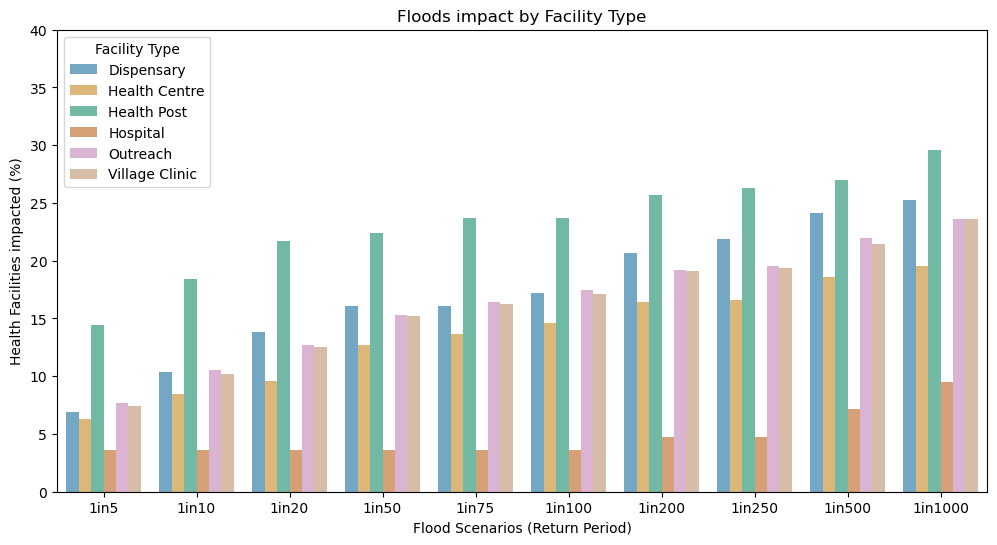

In [32]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Floods impact by Facility Type")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios (Return Period)")
ax0.set_ylabel("Health Facilities impacted (%)")
ax0.set_ylim(0,40)
ax0.legend(loc='upper left', fontsize = 10, title = "Facility type")
ax0 = sns.barplot(
    data=stats1_long, hue="Facility Type",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

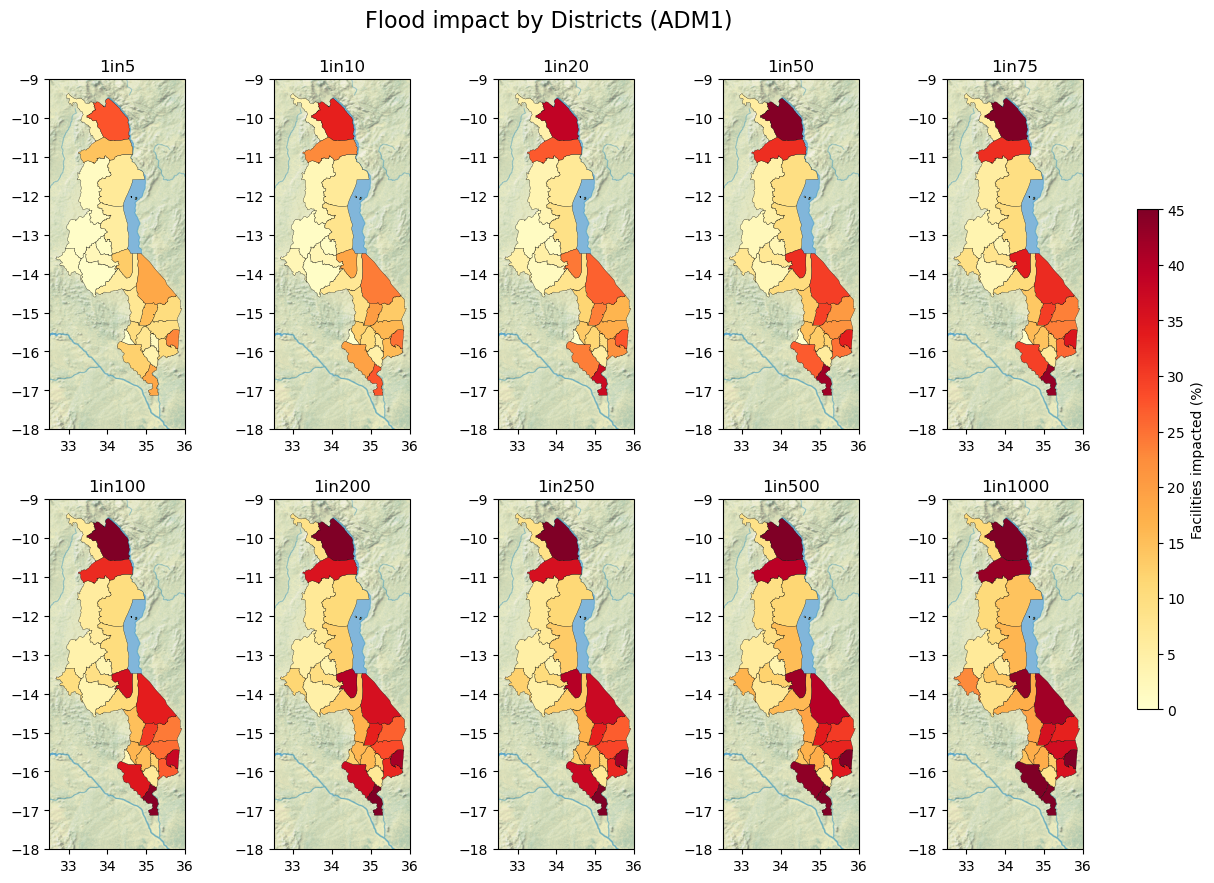

<Figure size 640x480 with 0 Axes>

In [34]:
figsize = (14, 10)
fig = plt.figure(figsize=figsize)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 5)

title = "Flood impact by Districts (ADM1)"
fig.suptitle(title, size=16, y=0.95)

# Define the colormap
cmap = plt.get_cmap('YlOrRd')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=45)

for i, flood in enumerate(scen):
    if i < 5:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-5], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    # Plot the data
    stats2.plot(
        ax=ax, column=flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )
    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# Add a colorbar to the figure, adjusting its position via `fig.add_axes`
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Facilities impacted (%)")

plt.show()
plt.savefig(join(out_path, iso, title + ".png"), dpi=300, bbox_inches='tight', facecolor='white')

### Flood impact on Roads

Consider the raw Fmax flood rasters, thus exploiting the original FATHOM dataset resolution.

Assumptions:

- Floods impact all roads except primary and secondary bridges.
- Roads are disrupted if Flood Depth is > 20 cm.
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.

Load OSM roads and define classification 
``` python
{
    'motorway': 'OSMLR level 1',
    'motorway_link': 'OSMLR level 1',
    'trunk': 'OSMLR level 1',
    'trunk_link': 'OSMLR level 1',
    'primary': 'OSMLR level 1',
    'primary_link': 'OSMLR level 1',
    'secondary': 'OSMLR level 2',
    'secondary_link': 'OSMLR level 2',
    'tertiary': 'OSMLR level 2',
    'tertiary_link': 'OSMLR level 2',
    'unclassified': 'OSMLR level 3',
    'unclassified_link': 'OSMLR level 3',
    'residential': 'OSMLR level 3',
    'residential_link': 'OSMLR level 3',
    'track': 'OSMLR level 4',
    'service': 'OSMLR level 4'
}
 ```

In [ ]:
# Only for the first time, need to download OSM .shp

# download_osm_shapefiles('africa', 'malawi', Path(join(data_dir, 'data', iso)))

In [27]:
# Load the Road network

roads = dask_gpd.read_file(join(data_dir, iso, "malawi-latest-free.shp", 'gis_osm_roads_free_1.shp'), npartitions = 8) #, chunksize = 100
roads = roads.to_crs(epsg)
roads['OSMLR'] = roads['fclass'].map(osm.OSMLR_Classes)
def get_num(x):
    try:
        return(int(x))
    except:
        return(5)
roads['OSMLR_num'] = roads['OSMLR'].apply(lambda x: get_num(str(x)[-1]))


In [28]:
# Create Polygons only from those cells where mask = True (water level >= 20 cm) 
def raster_cells_to_polygons(mask, transform):
    
    polygons = []
    for (row, col), value in np.ndenumerate(mask):
            if value:         # Only create polygons where the mask is True
                # Get the coordinates of the top left corner of the cell
                top_left = rio.transform.xy(transform, row, col, offset='ul')
                # Since each cell is a square, calculate the bottom right corner
                bottom_right = rio.transform.xy(transform, row+1, col+1, offset='ul')
                # Create a polygon from these coordinates
                polygon = box(top_left[0], bottom_right[1], bottom_right[0], top_left[1])
                polygons.append(polygon)
                
    return polygons

In [64]:
def flood_disruption_roads(roads_shp, flood_tif):

    flood_road = flood_tif.read(1).copy()
    # Floods can impact all the roads, except the bridges in primary and secondary roads
    roads_safe_crit = ((roads_shp['bridge'] == "T") & ((roads_shp['OSMLR_num'] == 1) | (roads_shp['OSMLR_num'] == 2)))
    roads_safe = roads_shp[roads_safe_crit]
    roads_flood = roads_shp[~roads_safe_crit]
    
    # If water level is more than 20 cm, the road is disrupted       
    flood_road = flood_road    # Need to explicitly open the rasterio within the dictionary to compute weights
    transf = flood_tif.transform
    mask = (flood_road >= 0.2)

    # Vectorize the masked cells
    flood_poly = raster_cells_to_polygons(mask, transf)
    flood_poly_gdf = gpd.GeoDataFrame(geometry=flood_poly, crs=epsg)  # Make sure to set the correct CRS

    # Remove the flooded roads
    intersections_dask = dask_gpd.sjoin(roads_flood[["osm_id", "fclass","bridge","geometry","OSMLR"]], flood_poly_gdf, how="inner", op='intersects')  
    intersections = intersections_dask.compute()
    intersections.drop_duplicates(subset="osm_id", inplace = True)

    # Convert from dask_gpd to gpd
    roads_shp = roads_shp.compute()
    roads_safe = roads_safe.compute()
    
    roads_impact = roads_shp.drop(intersections.index)

    # Add road types excluded from the analysis
    roads_final = pd.concat([roads_impact, roads_safe], axis = 0)
    
    # Export the disrupted roads shapefile
    roads_final.to_file(file, index = False)
    
    return roads_final

In [182]:
%%time

checkDir(join(out_path,iso,"vector"))

roads_impact = dict()
for key in flood_dict.keys():
    file = join(out_path,iso,"vector","roads_impact_"+key+"_new.shp")
    if not os.path.isfile(file):
        print("Computing scenario: " + key)
        roads_impact[key] = flood_disruption_roads(roads, flood_dict[key])
    else:
        print("Reading " + file)
        roads_impact[key] = dask_gpd.read_file(file, npartitions = 8)

Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in500_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in20_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in75_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in50_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in5_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in100_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in250_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in1000_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in200_new.shp
Reading /home/jupyter-wb618081/Health-Access-Metrics/Output/MWI/vector/roads_impact_1in10_new.shp
CPU times: user

### Access to Roads

Percentage of Health Facilities having direct access to an all-season road, by district (admin-2 level).​

Assumptions:

- All Health facilities considered are: Hospital, Health Post, Village Clinic, Health Centre, Dispensary and Outreach
- All-season road defined as primary and secondary or tertiary using the OpenStreetMap classification.
- Direct access defined as being within 100 m and 2 km of a road.​

In [122]:
import geopandas as gpd

def roads_access_buffer(dest_gdf, roads_gdf, buffer_dist=100, utm=epsg_utm, road_importance=None):
    ''' 
    Compute the accessibility of destinations according to their distance from roads
    
    INPUT
    dest_gdf [geopandas.GeoDataFrame] - destinations GeoDataFrame from which to compute roads access
    roads_gdf [geopandas.GeoDataFrame] - roads GeoDataFrame from which to apply the buffer distance
    buffer_dist [int] - buffer distance in meters
    utm [str] - UTM projection to use
    road_importance [int, optional] - threshold for road importance
    
    RETURNS
    geopandas.GeoDataFrame - destinations GeoDataFrame with boolean access column
    '''
    
    dest_gdf_buff = dest_gdf.copy().to_crs(utm)
    
    # Calculate buffers
    roads_buff = roads_gdf.copy().to_crs(utm)
    roads_buff['geometry'] = roads_buff['geometry'].buffer(buffer_dist)
    
    # Filter roads based on importance if specified
    if road_importance is not None:
        roads_buff = roads_buff.loc[roads_buff['OSMLR_num'] <= road_importance]
    
    # Intersect roads and buffer
    matched_index = gpd.sjoin(dest_gdf_buff, roads_buff, how="inner", op='intersects').index

    # Create dynamic column name
    col_name = f'bool_{road_importance}_{buffer_dist}m' if road_importance is not None else f'bool_all_{buffer_dist}m'
    dest_gdf_buff[col_name] = dest_gdf_buff.index.isin(matched_index)
        
    dest_gdf_buff = dest_gdf_buff.to_crs(dest_gdf.crs)
    
    return dest_gdf_buff


In [123]:
def roads_access_buffer_dask(dest_gdf, roads_gdf, buffer_dist=100, utm='epsg:utm', road_importance=None):
    ''' 
    Compute the accessibility of destinations according to their distance from roads
    
    INPUT
    dest_gdf [dask_geopandas.GeoDataFrame] - destinations GeoDataFrame from which to compute roads access
    roads_gdf [dask_geopandas.GeoDataFrame] - roads GeoDataFrame from which to apply the buffer distance
    buffer_dist [int] - buffer distance in meters
    utm [str] - UTM projection to use
    road_importance [int, optional] - threshold for road importance
    
    RETURNS
    dask_geopandas.GeoDataFrame - destinations GeoDataFrame with boolean access column
    '''
    
    # Convert coordinate reference systems
    dest_gdf_buff = dest_gdf.map_partitions(lambda df: df.to_crs(utm), meta=gpd.GeoDataFrame())
    roads_buff = roads_gdf.map_partitions(lambda df: df.to_crs(utm), meta=gpd.GeoDataFrame())
    
    # Calculate buffers
    roads_buff['geometry'] = roads_buff['geometry'].map_partitions(lambda x: x.buffer(buffer_dist))
    
    # Filter roads based on importance if specified
    if road_importance is not None:
        roads_buff = roads_buff.query(f'OSMLR_num <= {road_importance}')
    
    # Intersect roads and buffer
    dest_gdf_buff = dask_gpd.sjoin(dest_gdf_buff, roads_buff, how="inner", predicate='intersects')
    
    # Create dynamic column name
    col_name = f'bool_{road_importance}_{buffer_dist}m_baseline' if road_importance is not None else f'bool_all_{buffer_dist}m_baseline'
    
    # Intersect roads and buffer using map_partitions
    def spatial_join_and_create_column(dest, roads, col_name):
        joined = gpd.sjoin(dest, roads, how="inner", predicate='intersects')
        dest[col_name] = dest.index.isin(joined.index)
        return dest
   
    dest_gdf = dest_gdf.map_partitions(lambda df: spatial_join_and_create_column(df, roads_gdf.compute(), col_name), meta=gpd.GeoDataFrame())
    
    # final_gdf = final_gdf.to_crs(dest_gdf.crs)
    final_gdf = final_gdf.map_partitions(lambda df: df.to_crs(dest_gdf.crs), meta=gpd.GeoDataFrame())

    out_gdf = final_gdf.compute()
    
    return out_gdf

# Example usage (assuming you have Dask GeoDataFrames `dask_dest_gdf` and `dask_roads_gdf`)
# result = roads_access_buffer(dask_dest_gdf, dask_roads_gdf, buffer_dist=100, utm='epsg:32633', road_importance=2)
# result.compute() # To trigger computation and get the final GeoDataFrame

%%time

geodf_hf_dask = dask_gpd.from_geopandas(geodf_hf, npartitions=8)
roads_access_buffer_dask(geodf_hf_dask, roads, buffer_dist=100, utm=epsg_utm, road_importance=2)

#### Baseline

In [154]:
%%time

data_health = geodf_hf.copy()
buffer_zones = [100, 2000]
for b in buffer_zones:
    content = roads_access_buffer(geodf_hf, roads_impact[key].compute(), buffer_dist=b, utm=epsg_utm, road_importance=2).filter(regex='^bool_')
    col = content.columns[0]
    content = content.rename(columns={col:col + "_baseline"})
    data_health = pd.concat([data_health, content], axis = 1)

CPU times: user 3min 34s, sys: 46.6 s, total: 4min 21s
Wall time: 4min 20s


In [216]:
adm1 = adm1.to_crs(epsg)
geodf_hf_road_base = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")

## Get percentages
res_osmlr = geodf_hf_road_base[['bool_2_100m_baseline','bool_2_2000m_baseline','ADM1']].groupby('ADM1').sum().compute()
res_count = geodf_hf_road_base[['ADM1','bool_2_100m_baseline']].groupby('ADM1').count().rename(columns={'bool_2_100m_baseline':'count'}).compute()
res_osmlr_pct_base = res_osmlr.apply(lambda x: (x/res_count['count'])*100)
res_osmlr_pct_base.reset_index(inplace = True)

res_osmlr_pct_base.head(2)

#### Flood Scenarios

In [211]:
%%time

data_health = geodf_hf.copy()
for key in roads_impact.keys():

    buffer_zones = [100, 2000]
    for b in buffer_zones:
        content = roads_access_buffer(geodf_hf, roads_impact[key].compute(), buffer_dist=b, utm=epsg_utm, road_importance=2).filter(regex='^bool_')
        col = content.columns[0]
        content = content.rename(columns={col:col + "_" + key})
        data_health = pd.concat([data_health, content], axis = 1)

CPU times: user 2min 8s, sys: 653 ms, total: 2min 9s
Wall time: 2min 8s


In [214]:
adm1 = adm1.to_crs(epsg)

geodf_hf_road = gpd.sjoin(data_health, adm1[['geometry']], how='left').drop(columns = "index_right")
## Get percentages
# res_osmlr = facilities[['bool_1_100m','bool_2_100m','bool_1_2km','bool_2_2km','WB_ADM2_CO']].groupby('WB_ADM2_CO').sum()
columns = [col for col in geodf_hf_road.columns if col.startswith("bool")]
res_osmlr = geodf_hf_road[columns+['ADM1']].groupby('ADM1').sum()
res_count = geodf_hf_road[["bool_2_100m_"+key,'ADM1']].groupby('ADM1').count().rename(columns={'bool_2_100m_'+key:'count'})
res_osmlr_pct = res_osmlr.apply(lambda x: (x/res_count['count'])*100)
res_osmlr_pct.reset_index(inplace = True)

res_osmlr_pct.head(2)

,ADM1,bool_2_100m_baseline_1in500,bool_2_2000m_baseline_1in500
0,Balaka,3.750000,27.812500
1,Blantyre,4.347826,39.130435


In [ ]:
geo_res_osmlr_pct_base = gpd.GeoDataFrame(res_osmlr_pct_base, geometry=adm1.geometry, crs=epsg)
geo_res_osmlr_pct = gpd.GeoDataFrame(res_osmlr_pct, geometry=adm1.geometry, crs=epsg)

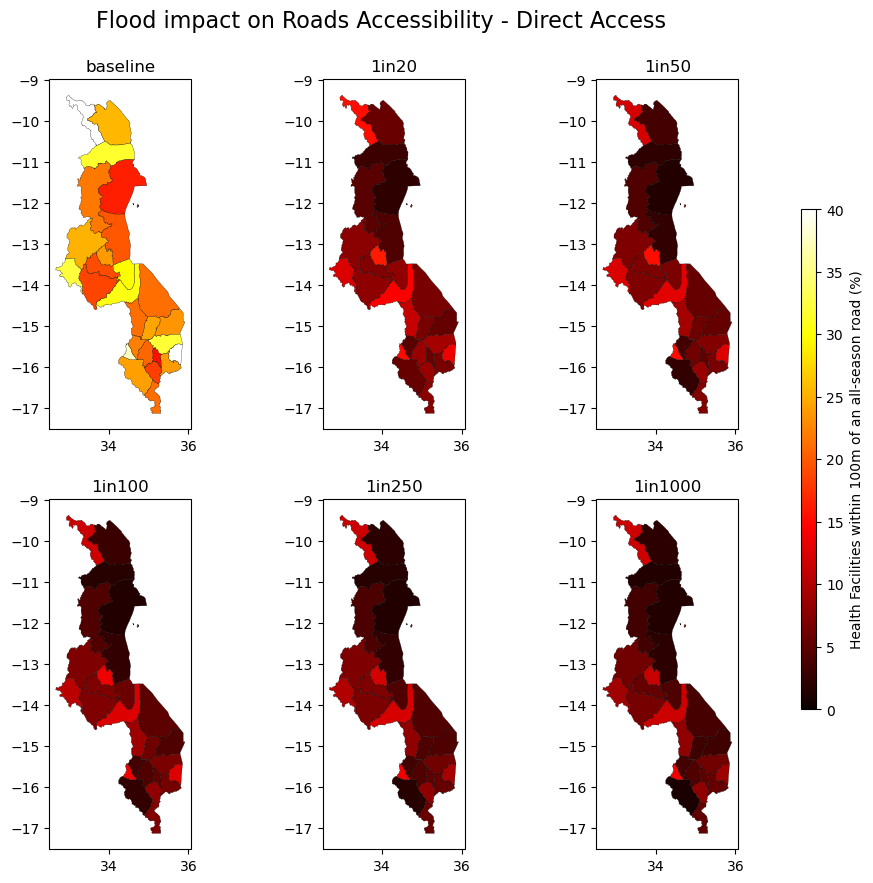

In [279]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

# Define the colormap
cmap = plt.get_cmap('hot')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=40)

scen_toplot = ["baseline", '1in20', '1in50', '1in100', '1in250', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    
    # Plot the data
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm = norm
    )

    else:
        geo_res_osmlr_pct.plot(
        ax=ax, column="bool_2_100m_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )

    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Health Facilities within 100m of an all-season road (%)")

plt.show()

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

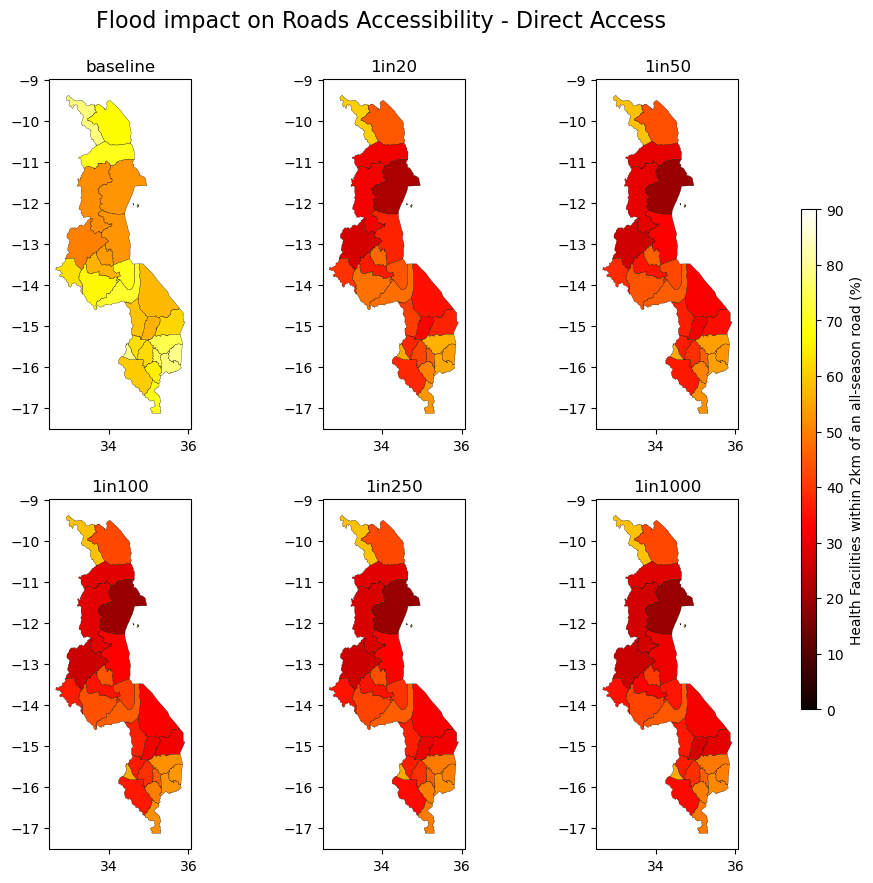

In [290]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 3)

fig.suptitle("Flood impact on Roads Accessibility - Direct Access", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

# Define the colormap
cmap = plt.get_cmap('hot')
# Define the normalization from 0 to 45
norm = colors.Normalize(vmin=0, vmax=90)

scen_toplot = ["baseline", '1in20', '1in50', '1in100', '1in250', '1in1000']
for i, flood in enumerate(scen_toplot):
    if i < 3:
        ax = fig.add_subplot(gs[0, i], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, i-3], projection=projection)

    ax.set_title(flood)
    ax.get_xaxis().set_visible(True)
    ax.get_yaxis().set_visible(True)

    
    # Plot the data
    if i == 0:
        geo_res_osmlr_pct_base.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm = norm
    )

    else:
        geo_res_osmlr_pct.plot(
        ax=ax, column="bool_2_2km_"+flood, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        norm=norm
    )


    ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # Adjust the position and size of the colorbar here
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Health Facilities within 2km of an all-season road (%)")

plt.show()

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

### Access to health disaggregated by wealth quintile

Categorize population grid by wealth quintiles, and then summarize the population with access to health (within 2 hours of health facility or hospital)

Hospitals

In [288]:
# Open Relative Wealth index and Population from Facebook
df_fb_rwi = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_relative_wealth_index.csv'))
geodf_fb = [Point(xy) for xy in zip(df_fb_rwi.longitude, df_fb_rwi.latitude)]
geodf_fb = gpd.GeoDataFrame(df_fb_rwi, crs=epsg, geometry=geodf_fb)
geodf_fb = gpd.sjoin(geodf_fb, adm1[['ADM1','geometry']])

df_fb_pop = pd.read_csv(os.path.join(data_dir, iso, 'meta', f'{iso.lower()}_general_2020.csv'))
df_fb_pop = df_fb_pop.rename(columns={f'{iso.lower()}_general_2020': 'pop_2020'})
    
df_fb_flood_hosp = dict()
for key in tt_rio_hosp.keys():

    # Zonal mean of RWI in tt_rio_hosp cells
    df_fb_flood_hosp[key] = pd.DataFrame(zonal_stats(geodf_fb, tt_rio_hosp[key].read(1, masked = True).filled(), affine=tt_rio_hosp[key].transform, stats='mean', nodata=tt_rio_hosp[key].nodata)).rename(columns={'mean':'tt_hospital_'+key})
    geodf_fb = geodf_fb.join(df_fb_flood_hosp[key])

    # Discretize in quantiles
    geodf_fb.loc[:, "rwi_cut_"+key] = pd.qcut(geodf_fb['rwi'], [0, .2, .4, .6, .8, 1.], labels=['lowest', 'second-lowest', 'middle', 'second-highest', 'highest'])
    
    # Merge RWI and population by matching the grid (quadkey)
    df_fb_pop['quadkey'+key] = df_fb_pop.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    geodf_fb['quadkey'+key] = geodf_fb.apply(lambda x: str(quadkey.from_geo((x['latitude'], x['longitude']), 14)), axis=1)
    bing_tile_z14_pop = df_fb_pop.groupby('quadkey'+key, as_index=False)['pop_2020'].sum()

    rwi = geodf_fb.merge(bing_tile_z14_pop[['quadkey'+key, 'pop_2020']], on='quadkey'+key, how='inner')

res_rwi_adm0 = pd.DataFrame()
res_rwi_adm1 = pd.DataFrame()
for key in tt_rio_hosp.keys():

    # Define boolean proximity within 2hrs from hospital
    rwi.loc[:,"tt_hospital_bool_" + key] = rwi['tt_hospital_'+key]<=2
    
    # Aggregate at country level (ADM0)
    pop_adm0 = rwi[['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum()
    hosp_adm0 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['rwi_cut_'+key, 'pop_2020']].groupby(['rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm0 = pop_adm0.join(hosp_adm0)
    res_rwi_adm0.loc[:, "hospital_pct_"+key] = rwi_adm0['pop_120_hospital_'+key]/rwi_adm0['pop_2020']

    # Aggregate at region level (ADM1)
    pop_adm1 = rwi[['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum()
    hosp_adm1 = rwi.loc[rwi["tt_hospital_bool_" + key]==True, ['ADM1','rwi_cut_'+key, 'pop_2020']].groupby(['ADM1','rwi_cut_'+key]).sum().rename(columns={'pop_2020':'pop_120_hospital_'+key})
    rwi_adm1 = pop_adm1.join(hosp_adm1)
    res_rwi_adm1.loc[:, "hospital_pct_"+key] = rwi_adm1['pop_120_hospital_'+key]/rwi_adm1['pop_2020']

res_rwi_adm0.reset_index(inplace = True)
res_rwi_adm0 = res_rwi_adm0.rename(columns={'rwi_cut_1in5':'quantiles'})

res_rwi_adm1.reset_index(inplace = True)
res_rwi_adm1 = res_rwi_adm1.rename(columns={'rwi_cut_1in5':'quantiles'})


In [324]:
def sort_flood_col(gdf, str_start, str_sep):
    # Define str_start and str_sep as the strings that identify the start of column names and the separator with the numerical value
    fd_columns = [col for col in gdf.columns if str_start in col]
    non_fd_columns = [col for col in gdf.columns if not str_start in col]
    fd_num = [(int(col.split(str_sep)[1]), col) for col in fd_columns]
    fd_col_sort = [col for _, col in sorted(fd_num)]
    new_column_order = non_fd_columns + fd_col_sort
    # Reorder the DataFrame columns
    gdf = gdf[new_column_order]
    return(gdf)

In [329]:
# Melting for seaborn plot
res_rwi_adm0 = sort_flood_col(res_rwi_adm0, "1in", "in")
res_rwi_adm0_long = pd.melt(res_rwi_adm0, id_vars="quantiles", var_name="scen")
res_rwi_adm0_long.value = res_rwi_adm0_long.value*100
scen = res_rwi_adm0_long.scen.unique()
scen = [s.split("_")[2] for s in scen]

res_rwi_adm1 = sort_flood_col(res_rwi_adm1, "1in", "in")
res_rwi_adm1_long = pd.melt(res_rwi_adm1, id_vars=["ADM1","quantiles"], var_name="scen")
res_rwi_adm1_long.value = res_rwi_adm1_long.value*100

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


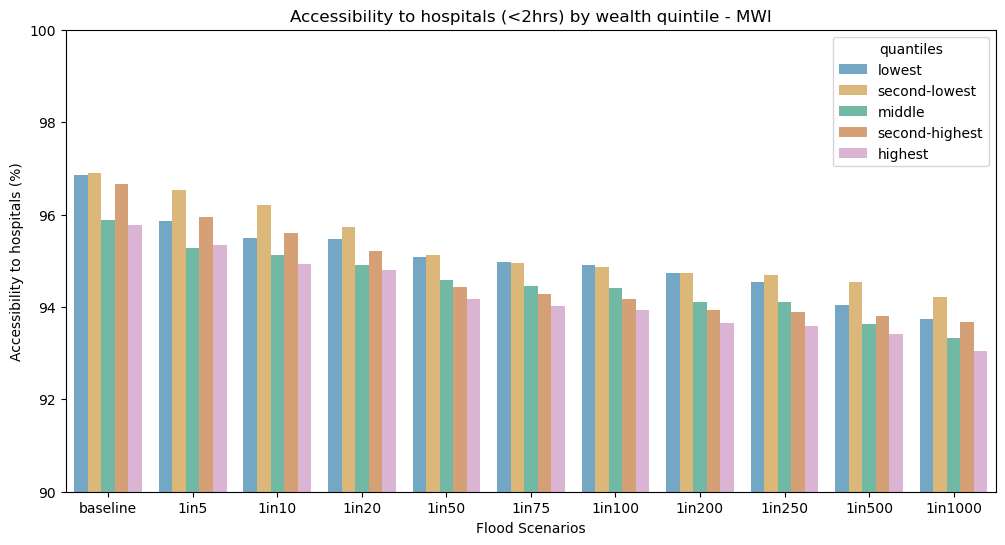

In [357]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile - " + iso)
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm0_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)

In [500]:
res_rwi_adm1["hospital_pct_impact"] = (res_rwi_adm1["hospital_pct_1in1000"] - res_rwi_adm1["hospital_pct_baseline"])/res_rwi_adm1["hospital_pct_baseline"]

In [501]:
test = res_rwi_adm1.copy()
test = test[["ADM1", "quantiles", "hospital_pct_impact"]]

quant = pd.DataFrame(test["ADM1"].unique())
for q in test.quantiles.unique().to_list():
    quant["hospital_pct_impact_"+ q] = test[test["quantiles"] == q]["hospital_pct_impact"].values.round(3)*100
    
quant = quant.rename(columns = {quant.columns[0]:"ADM1"})
quant = quant.merge(right = adm1[["ADM1",'geometry']], on = "ADM1", how = "left")
quant = gpd.GeoDataFrame(quant, crs=epsg, geometry="geometry")
# quant = quant*100
quant.head(2)

,ADM1,hospital_pct_impact_lowest,hospital_pct_impact_second-lowest,hospital_pct_impact_middle,hospital_pct_impact_second-highest,hospital_pct_impact_highest,geometry
0,Balaka,0.0,-0.5,-2.1,-2.0,-1.5,"MULTIPOLYGON (((35.07923 -15.30382, 35.07925 -..."
1,Blantyre,-5.5,-2.1,0.0,-6.6,-2.1,"MULTIPOLYGON (((34.94884 -15.98430, 34.94793 -..."


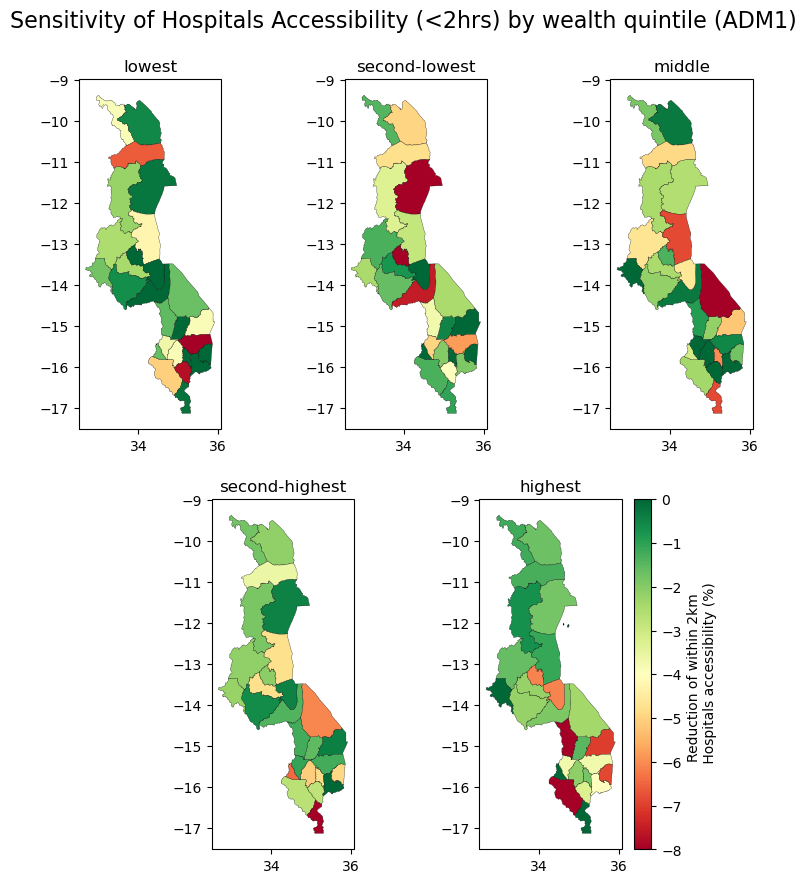

In [502]:
import matplotlib.gridspec as gridspec
import cartopy.feature as cfeature
os.environ['CARTOPY_USER_BACKGROUNDS'] = 'C:/Users/wb618081/OneDrive - WBG/Python/Backgrounds/'

figsize = (10,10)
fig = plt.figure(figsize=figsize) #, constrained_layout=True)
projection = ccrs.PlateCarree()
gs = gridspec.GridSpec(2, 6)

fig.suptitle("Sensitivity of Hospitals Accessibility (<2hrs) by wealth quintile (ADM1)", size = 16, y = 0.95)
# fonttitle = {'fontname':'Open Sans','weight':'bold','size':14}

for i, q in enumerate(quant.columns[1:6]):
    if i < 3:
        ax = fig.add_subplot(gs[0, 2 * i : 2 * i + 2], projection=projection)
    else:
        ax = fig.add_subplot(gs[1, 2 * i - 5 : 2 * i - 3], projection=projection)

    ax.set_title(q.split("_")[3])
    ax.get_xaxis().set_visible(True) # plt.axis('off')
    ax.get_yaxis().set_visible(True)
    
    cmap = "RdYlGn"

    if i == 4:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=True,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "user defined", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'label': "Reduction of within 2km \n Hospitals accessibility (%)",
            # "loc": "upper right",
            # "bbox_to_anchor": (2.7, 1), 
            # 'fontsize': 10,
            # 'fmt': "{:.0%}",
            # 'title_fontsize': 12
        }
    )
    else:
        quant.plot(
        ax=ax, column=q, cmap=cmap, legend=False,
        alpha=1, linewidth=0.2, edgecolor='black', 
        # scheme = "naturalbreaks", classification_kwds = {'bins': [-0.02,-0.04,-0.6,-0.08,-0.10,-0.12]},
        legend_kwds = {
            'title': "Reduction of within 2km \n Hospitals accessibility (%)",
            "loc": "upper right",
            "bbox_to_anchor": (2.7, 1), 
            'fontsize': 10,
            'fmt': "{:.0%}",
            'title_fontsize': 12
        }
    )
        
    # ax.background_img(name='NaturalEarthRelief', resolution='high', extent = [32.5, 36, -18, -9])

# plt.savefig(os.path.join(scratch_dir, "Health_Access.png"), dpi=150, bbox_inches='tight', facecolor='white')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


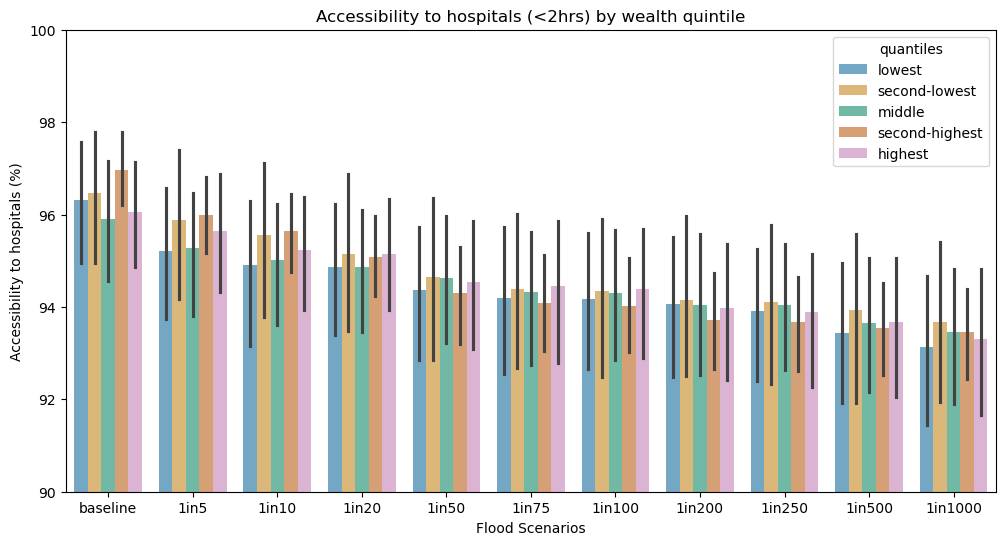

In [355]:
fig = plt.figure(figsize=(12, 6))

ax0 = fig.add_subplot(111)
ax0.set_title("Accessibility to hospitals (<2hrs) by wealth quintile")
ax0.set_xticklabels(scen)
ax0.set_xlabel("Flood Scenarios")
ax0.set_ylabel("Accessibility to hospitals (%)")
ax0.set_ylim(90,100)
ax0.legend(loc='upper left', fontsize = 10, title = "RWI quantiles")
ax0 = sns.barplot(
    data=res_rwi_adm1_long, hue="quantiles",# errorbar=("pi", 50),
    x="scen", y="value",
    palette='colorblind', alpha=.6, 
)